# Group Project: Early Prediction of Sepsis Onset from Clinical Time Series

Authors:  

Christian Mardini

Majid Makhoul  

## Imports

In [21]:
from utility_functions import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, joblib
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score, accuracy_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
os.makedirs('models', exist_ok=True)

Using device: cpu


## Load Data

The SepsisExp dataset consists of ICU clinical time series, with measurements recorded every 30 minutes. It includes patients who go on to develop sepsis or never do. The severity column reflects how the condition progresses over time: 0 indicates no sepsis (or the pre-sepsis/healthy phase), 1–4 represent increasingly severe sepsis stages. The sepsis column is a patient-level binary label that stays constant for each patient and indicates whether they eventually develop sepsis (1 = yes).

All four splits (A–D) are loaded and combined into a single dataframe.

In [22]:
# Load all four partitions
partitions = ['A', 'B', 'C', 'D']
dfs = []
for part in partitions:
    path = f'raw_data/sepsisexp_timeseries_partition-{part}.tsv'
    df_part = pd.read_csv(path, sep='\t')
    dfs.append(df_part)
    print(f'Partition {part}: {df_part.shape[0]:,} rows, {df_part["id"].nunique()} patients')

df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal: {df.shape[0]:,} rows, {df["id"].nunique()} patients')

# Define clinical feature columns (exclude the metadata)
META_COLS = ['id', 'sepsis', 'severity', 'timestep']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]
print(f'{len(FEATURE_COLS)} clinical features')

Partition A: 156,704 rows, 319 patients
Partition B: 152,155 rows, 319 patients
Partition C: 156,219 rows, 319 patients
Partition D: 137,490 rows, 318 patients

Total: 602,568 rows, 1275 patients
43 clinical features


## Task 1: Exploratory Data Analysis

Before modelling, we first examine the dataset to get a clearer picture of: 1. how balanced the classes are, 2. when sepsis typically starts across patients, 3. how important clinical markers differ between patients who develop sepsis and those who don’t.

In [23]:
# Patient-level statistics
patient_info = df.groupby('id').agg(
    sepsis=('sepsis', 'first'),
    n_timesteps=('timestep', 'count'),
    max_severity=('severity', 'max')
).reset_index()

# Sepsis onset time: first timestep, severity > 0
onset_times = (
    df[(df['sepsis'] == 1) & (df['severity'] > 0)]
    .groupby('id')['timestep'].min()
    .rename('onset_time')
)
patient_info = patient_info.merge(onset_times, on='id', how='left')

n_sepsis = patient_info['sepsis'].sum()
n_total  = len(patient_info)
print(f'Total patients : {n_total}')
print(f'Sepsis         : {n_sepsis} ({n_sepsis/n_total:.1%})')
print(f'Non-sepsis     : {n_total - n_sepsis} ({(n_total-n_sepsis)/n_total:.1%})')

Total patients : 1275
Sepsis         : 296 (23.2%)
Non-sepsis     : 979 (76.8%)


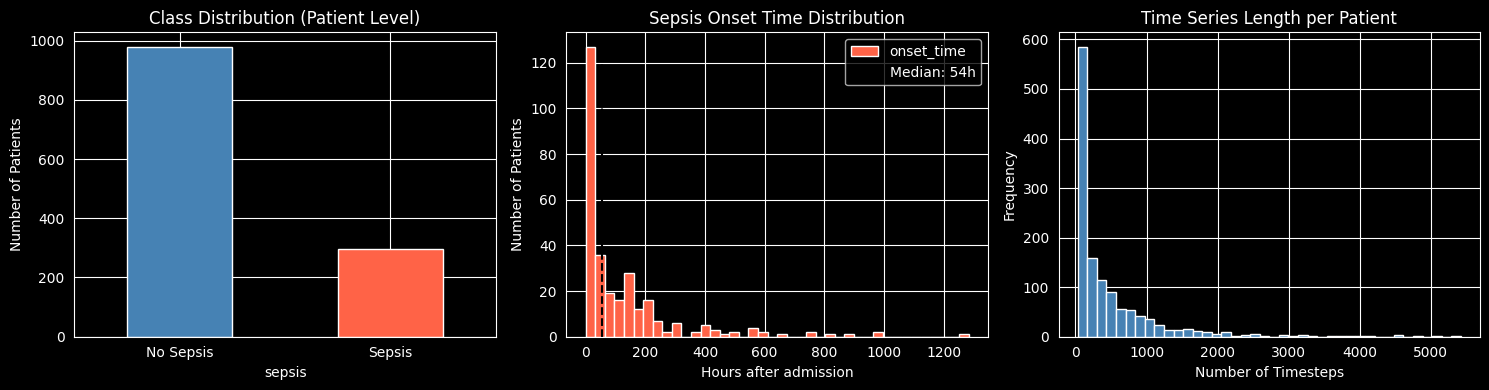

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Class distribution
patient_info['sepsis'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_xticklabels(['No Sepsis', 'Sepsis'], rotation=0)
axes[0].set_title('Class Distribution (Patient Level)')
axes[0].set_ylabel('Number of Patients')

# 2. Distribution of onset times
onset_hours = patient_info.dropna(subset=['onset_time'])['onset_time']
onset_hours.plot(kind='hist', bins=40, ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Sepsis Onset Time Distribution')
axes[1].set_xlabel('Hours after admission')
axes[1].set_ylabel('Number of Patients')
axes[1].axvline(onset_hours.median(), color='black', linestyle='--', label=f'Median: {onset_hours.median():.0f}h')
axes[1].legend()

# 3. Time series length distribution
patient_info['n_timesteps'].plot(kind='hist', bins=40, ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Time Series Length per Patient')
axes[2].set_xlabel('Number of Timesteps')

plt.tight_layout()
plt.show()

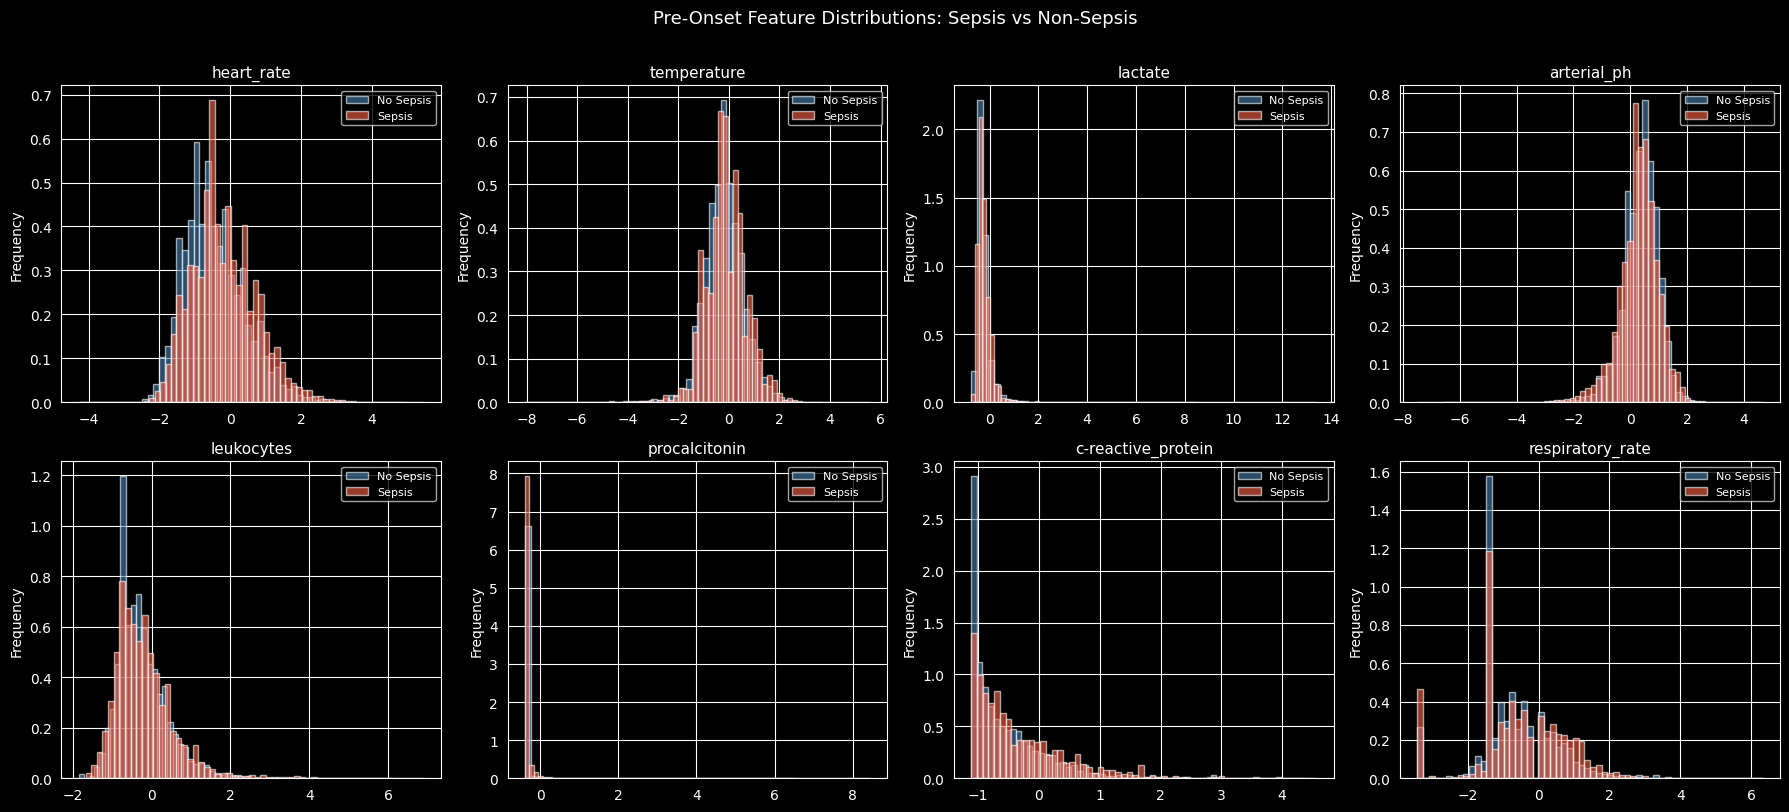

In [25]:
# Compare key clinical features between sepsis and non-sepsis populations
# Compare pre-onset data only (severity == 0) to avoid data leakage
pre_onset = df[df['severity'] == 0].copy()

plot_feats = [
    'heart_rate', 'temperature', 'lactate', 'arterial_ph',
    'leukocytes', 'procalcitonin', 'c-reactive_protein', 'respiratory_rate'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(plot_feats):
    pre_onset[pre_onset['sepsis'] == 0][feat].plot(
        kind='hist', bins=60, alpha=0.6, ax=axes[i],
        label='No Sepsis', color='steelblue', density=True
    )
    pre_onset[pre_onset['sepsis'] == 1][feat].plot(
        kind='hist', bins=60, alpha=0.6, ax=axes[i],
        label='Sepsis', color='tomato', density=True
    )
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Pre-Onset Feature Distributions: Sepsis vs Non-Sepsis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Discussion**: Even before sepsis is identified (severity = 0), patients who later develop sepsis already tend to show higher lactate, procalcitonin and CRP, along with a lower arterial pH. This aligns with prior research suggesting these are early warning signs. At the same time, the dataset is imbalanced (around 25% sepsis), and onset timing varies widely—from a few hours to several days—which makes early-warning prediction particularly challenging

## Task 2: Data Preparation, Sliding Window Labelling

### Design Motivation

The main challenge is to define the prediction task in a way that matches the “early warning” goal. To do this, we use a sliding window setup:

- For each patient, we generate fixed-length windows containing `W` consecutive timesteps.
- A window is labelled **positive (1)** if:

the patient eventually develops sepsis,

the sepsis onset occurs within the next `H` hours after the final timestep in the window, and

the window itself contains only pre-onset data (i.e., `severity == 0` for every timestep in the window).

A window is labelled **negative (0)** in all other cases.

This design gives two important guarantees: (a) the model is never trained on windows that already include sepsis onset signals, and (b) predictions are explicitly made at least H hours before onset. We evaluate three prediction horizons: **2h, 4h, and 6h**.

We set the window length to `W = 12 timesteps (i.e., 6 hours)`, which is long enough to capture short-term clinical trends without requiring an overly long patient history.

In [26]:
# Build sliding window dataset
# Returns X (windows), y (labels), patient_ids
def build_windows(df, feature_cols, window_size=12, horizon_hours=4, stride=2):
    """
    Parameters
    ----------
    window_size   : number of timesteps per window (12 = 6 hours)
    horizon_hours : predict sepsis onset within this many hours
    stride        : step between consecutive windows (reduces redundancy)
    """
    X_list, y_list, pid_list = [], [], []
    
    # Compute onset time per patient
    sepsis_ids = set(df[df['sepsis'] == 1]['id'].unique())
    onset_map = (
        df[(df['sepsis'] == 1) & (df['severity'] > 0)]
        .groupby('id')['timestep'].min()
        .to_dict()
    )
    
    for pid, group in df.groupby('id'):
        group = group.sort_values('timestep').reset_index(drop=True)
        features = group[feature_cols].values
        times    = group['timestep'].values
        is_sepsis_patient = pid in sepsis_ids
        onset_t  = onset_map.get(pid, None)
        
        for start in range(0, len(group) - window_size + 1, stride):
            end = start + window_size
            window_end_time = times[end - 1]
            
            # Skip windows that already contain onset (no data leakage)
            if is_sepsis_patient and onset_t is not None:
                if window_end_time >= onset_t:
                    continue
            
            # Label: onset happens within horizon_hours after window end
            if is_sepsis_patient and onset_t is not None:
                label = int(0 < (onset_t - window_end_time) <= horizon_hours)
            else:
                label = 0
            
            X_list.append(features[start:end])
            y_list.append(label)
            pid_list.append(pid)
    
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64), np.array(pid_list)

WINDOW_SIZE = 12   # 6 hours of 30-min measurements
STRIDE = 2         # Step every 1 hour to reduce redundancy

print('Building windows for each prediction horizon...')
datasets = {}
for horizon in [2, 4, 6]:
    X, y, pids = build_windows(df, FEATURE_COLS, window_size=WINDOW_SIZE, 
                                horizon_hours=horizon, stride=STRIDE)
    datasets[horizon] = (X, y, pids)
    pos = y.sum()
    print(f'  {horizon}h horizon: {len(y):,} windows, {pos} positive ({pos/len(y):.2%})')

Building windows for each prediction horizon...
  2h horizon: 148,307 windows, 506 positive (0.34%)
  4h horizon: 148,307 windows, 964 positive (0.65%)
  6h horizon: 148,307 windows, 1388 positive (0.94%)


## Task 3: Model Architecture

### Architecture Choice: Temporal Convolutional Network + GRU (TCN-GRU)

We use a **hybrid TCN–GRU** model to capture both short-term patterns and longer temporal dependencies in the clinical time windows:

1. **1D convolutional front-end (TCN-style):**
The convolutional layers act as a feature extractor over the 43 clinical variables, learning local temporal motifs within each window. Using dilated convolutions helps the model pick up patterns at multiple time scales (for instance, brief spikes versus slower drifts). Batch normalisation is included to stabilise training given that physiological variables can vary widely in magnitude.

2. **Bidirectional GRU:**
After the convolutional features are extracted, a bi-directional GRU models dependencies across the entire window. We choose a GRU rather than an LSTM mainly for efficiency: it has fewer parameters, which can help reduce overfitting when positive (sepsis) examples are limited. The bidirectional setup allows the model to use information from the whole window when producing a window-level prediction.

3. **Attention mechanism:**
To avoid treating all timesteps as equally informative, we add learned attention pooling on top of the GRU outputs. This lets the model focus more on the parts of the window that matter most—especially relevant in sepsis, where early deterioration signals often become clearer closer to onset.

4. **Dropout (p = 0.3):**
Dropout is applied after the convolutional block and the GRU layer for regularisation. A rate of 0.3 provides meaningful regularisation without discarding too much information, which is important given the relatively short 6-hour windows.

5. **Output layer:**
A single neuron with sigmoid activation produces the final probability for binary classification: whether sepsis onset occurs within the chosen prediction horizon.

In [27]:
class AttentionPool(nn.Module):
    """Weighted average pooling over the time dimension."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        # x: (batch, seq, hidden)
        scores = self.attn(x).squeeze(-1)
        weights = torch.softmax(scores, dim=-1)
        return (x * weights.unsqueeze(-1)).sum(dim=1)


class TCN_GRU(nn.Module):
    """
    Hybrid Temporal Convolutional Network + Bidirectional GRU with Attention.
    
    Architecture:
      Input: (batch, seq_len, n_features)
      -> Conv1D block (kernel=3, dilation=1) with BatchNorm + ReLU + Dropout
      -> Conv1D block (kernel=3, dilation=2) with BatchNorm + ReLU + Dropout
      -> Bidirectional GRU (hidden=64, layers=2)
      -> Attention pooling
      -> Linear(128 -> 64) + ReLU + Dropout
      -> Linear(64 -> 1) + Sigmoid
    """
    def __init__(self, n_features, conv_channels=64, gru_hidden=64, dropout=0.3):
        super().__init__()
        
        # TCN front-end: two dilated conv blocks
        self.conv_block = nn.Sequential(
            # Block 1: dilation=1, captures immediate temporal patterns
            nn.Conv1d(n_features, conv_channels, kernel_size=3, padding=1, dilation=1),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Block 2: dilation=2, captures patterns at 2x timescale
            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding=2, dilation=2),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        # Bidirectional GRU
        self.gru = nn.GRU(
            input_size=conv_channels,
            hidden_size=gru_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        
        # Attention pooling over time
        self.attention = AttentionPool(gru_hidden * 2)  # *2 for bidirectional
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(gru_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # Permute to (batch, features, seq) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.conv_block(x)
        # Back to (batch, seq, channels) for GRU
        x = x.permute(0, 2, 1)
        x, _ = self.gru(x)
        x = self.attention(x)
        return self.classifier(x).squeeze(-1)


# Verify model shape
model_test = TCN_GRU(n_features=len(FEATURE_COLS))
dummy = torch.randn(4, WINDOW_SIZE, len(FEATURE_COLS))
out = model_test(dummy)
print(f'Model output shape: {out.shape}  (expected: [4])')
n_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Total trainable parameters: {n_params:,}')

Model output shape: torch.Size([4])  (expected: [4])
Total trainable parameters: 153,794


## Task 4: Training Strategy
### Design decisions: 

- **Cross-validation strategy:** We use **5-fold stratified cross-validation** at the patient level. Splitting by patient ID (rather than by individual windows) is essential to avoid leakage otherwise, early windows from the same patient could end up in training while later windows appear in the test fold.

- **Handling class imbalance:** Positive windows are extremely uncommon in our labelled datasets (approximately **0.34% at 2h, 0.65% at 4h, and 0.94% at 6h**). In the implemented training pipeline, we handle this primarily through **oversampling of positive training windows** so that the model sees enough minority-class examples during optimisation. We compute the class ratio for inspection, but in the final code we do **not** apply `pos_weight` in the loss.

- **Optimiser:** AdamW with a weight decay of 1e-4. Compared with standard Adam, AdamW applies weight decay in a cleaner way, which often improves generalisation.

- **Learning rate schedule:** Cosine annealing, decreasing the learning rate from 1e-3 to 1e-5 across training. This encourages fast progress early on, then more careful refinement later.

- **Early stopping:** We use patience of 10 epochs, monitoring validation AUC-PR. AUC-PR is more informative than accuracy under heavy imbalance predicting “no sepsis” for every window could still yield anout 98% accuracy, but it would be useless clinically and would collapse the precision–recall performance.

- **Batch size:** 64-large enough for stable batch normalisation, but still small enough to provide some regularisation.

- **Epoch budget:** Up to 60 epochs, although early stopping typically ends training around 30-45 epochs.

- **Primary objective:** We prioritise **AUC-PR and recall (sensitivity)**. In a clinical early-warning setting, missing a true sepsis case (a false negative) is generally more serious than raising an unnecessary alert. However, the reported precision / recall / F1 values in this notebook are computed at the **default threshold of 0.5**

- **Effect of architecture on training strategy:** The bidirectional GRU with two layers required dropout both between GRU layers and in the classifier head to prevent overfitting, the relatively small number of positive samples (~1–3% of windows) makes the model prone to memorising training patterns. The attention mechanism reduced the need for longer windows: because the model can learn to focus on the most informative timesteps, a 6-hour window (12 timesteps) was sufficient rather than requiring 12–24 hours of history. The BatchNorm layers in the TCN front-end made training stable without requiring a very small learning rate, enabling the use of a higher initial LR (1e-3) with cosine decay.

In [28]:
def oversample_positives(X, y, factor=5):
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    # Repeat positives
    pos_idx_rep = np.tile(pos_idx, factor)
    all_idx = np.concatenate([neg_idx, pos_idx_rep])
    np.random.shuffle(all_idx)
    return X[all_idx], y[all_idx]


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.float().to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_model(model, loader, criterion, device):
    model.eval()
    all_probs, all_labels, total_loss = [], [], 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.float().to(device)
            probs = model(X_batch)
            loss = criterion(probs, y_batch)
            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return np.array(all_probs), np.array(all_labels), total_loss / len(loader)


def train_fold(X_tr, y_tr, X_val, y_val, n_features, device,
               max_epochs=60, patience=10, batch_size=64):
    
    # Oversample training positives
    X_tr_os, y_tr_os = oversample_positives(X_tr, y_tr, factor=5)
    
    # Compute pos_weight for BCELoss
    n_neg = (y_tr == 0).sum()
    n_pos = (y_tr == 1).sum()
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)
    
    # DataLoaders
    train_ds = TensorDataset(torch.FloatTensor(X_tr_os), torch.LongTensor(y_tr_os))
    val_ds   = TensorDataset(torch.FloatTensor(X_val),   torch.LongTensor(y_val))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    
    model     = TCN_GRU(n_features=n_features).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-5)
    criterion = nn.BCELoss()  # pos_weight applied via oversampling instead
    
    best_auc_pr = 0
    best_state  = None
    no_improve  = 0
    history     = {'train_loss': [], 'val_loss': [], 'val_auc_pr': []}
    
    for epoch in range(max_epochs):
        tr_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_probs, val_labels, val_loss = eval_model(model, val_loader, criterion, device)
        scheduler.step()
        
        # AUC-PR as main monitoring metric
        auc_pr = average_precision_score(val_labels, val_probs) if val_labels.sum() > 0 else 0
        
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['val_auc_pr'].append(auc_pr)
        
        if auc_pr > best_auc_pr:
            best_auc_pr = auc_pr
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1
        
        if no_improve >= patience:
            print(f'    Early stopping at epoch {epoch+1}')
            break
    
    model.load_state_dict(best_state)
    return model, best_auc_pr, history

print('Training functions defined.')

Training functions defined.


In [29]:
# Run 5-fold patient-level cross-validation for each horizon

N_FOLDS = 5
all_results = {}  # horizon -> fold results

for horizon in [2, 4, 6]:
    print(f'\n{"="*55}')
    print(f'  Horizon: {horizon} hours')
    print(f'{"="*55}')
    
    X, y, pids = datasets[horizon]
    
    # Get unique patients and their labels for stratified split
    pid_unique = np.unique(pids)
    # Patient-level label: 1 if they have any positive windows
    pid_has_pos = np.array([
        int(y[pids == pid].sum() > 0) for pid in pid_unique
    ])
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    fold_results = []
    best_model_overall = None
    best_auc_overall   = 0
    
    for fold_idx, (tr_pid_idx, val_pid_idx) in enumerate(skf.split(pid_unique, pid_has_pos)):
        tr_pids  = pid_unique[tr_pid_idx]
        val_pids = pid_unique[val_pid_idx]
        
        tr_mask  = np.isin(pids, tr_pids)
        val_mask = np.isin(pids, val_pids)
        
        X_tr, y_tr = X[tr_mask], y[tr_mask]
        X_val, y_val = X[val_mask], y[val_mask]
        
        print(f'  Fold {fold_idx+1}/{N_FOLDS} | '
              f'Train: {len(y_tr):,} ({y_tr.sum()} pos) | '
              f'Val: {len(y_val):,} ({y_val.sum()} pos)')
        
        model, best_ap, history = train_fold(
            X_tr, y_tr, X_val, y_val,
            n_features=len(FEATURE_COLS),
            device=DEVICE
        )
        
        # Evaluate fold
        val_ds     = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
        val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
        criterion  = nn.BCELoss()
        val_probs, val_labels, _ = eval_model(model, val_loader, criterion, DEVICE)
        
        # Threshold = 0.5 for standard metrics
        val_preds = (val_probs >= 0.5).astype(int)
        
        metrics = {
            'fold': fold_idx + 1,
            'auc_roc': roc_auc_score(val_labels, val_probs) if val_labels.sum() > 0 else 0,
            'auc_pr':  average_precision_score(val_labels, val_probs) if val_labels.sum() > 0 else 0,
            'f1':      f1_score(val_labels, val_preds, zero_division=0),
            'recall':  recall_score(val_labels, val_preds, zero_division=0),
            'precision': precision_score(val_labels, val_preds, zero_division=0),
            'accuracy': accuracy_score(val_labels, val_preds),
            'val_probs': val_probs,
            'val_labels': val_labels,
            'history': history,
        }
        fold_results.append(metrics)
        print(f'    AUC-ROC={metrics["auc_roc"]:.3f}  AUC-PR={metrics["auc_pr"]:.3f}  '
      f'Accuracy={metrics["accuracy"]:.3f}  Recall={metrics["recall"]:.3f}  F1={metrics["f1"]:.3f}')
        
        # Save best model
        if metrics['auc_pr'] > best_auc_overall:
            best_auc_overall   = metrics['auc_pr']
            best_model_overall = model
    
    all_results[horizon] = fold_results
    
    # Save best model
    ts  = datetime.now().strftime('%y%m%d%H%M')
    acc = int(best_auc_overall * 100)
    fname = f'models/tcn_gru_{horizon}h_{acc}_{ts}'
    torch.save(best_model_overall.state_dict(), fname + '.pt')
    print(f'  -> Best model saved: {fname}.pt')


  Horizon: 2 hours
  Fold 1/5 | Train: 118,767 (404 pos) | Val: 29,540 (102 pos)
    Early stopping at epoch 13
    AUC-ROC=0.600  AUC-PR=0.025  Accuracy=0.989  Recall=0.039  F1=0.024
  Fold 2/5 | Train: 120,413 (404 pos) | Val: 27,894 (102 pos)
    Early stopping at epoch 12
    AUC-ROC=0.627  AUC-PR=0.009  Accuracy=0.981  Recall=0.039  F1=0.015
  Fold 3/5 | Train: 116,209 (404 pos) | Val: 32,098 (102 pos)
    Early stopping at epoch 18
    AUC-ROC=0.695  AUC-PR=0.013  Accuracy=0.984  Recall=0.069  F1=0.027
  Fold 4/5 | Train: 120,883 (406 pos) | Val: 27,424 (100 pos)
    Early stopping at epoch 23
    AUC-ROC=0.641  AUC-PR=0.009  Accuracy=0.989  Recall=0.020  F1=0.014
  Fold 5/5 | Train: 116,956 (406 pos) | Val: 31,351 (100 pos)
    Early stopping at epoch 15
    AUC-ROC=0.655  AUC-PR=0.016  Accuracy=0.970  Recall=0.040  F1=0.008
  -> Best model saved: models/tcn_gru_2h_2_2603111215.pt

  Horizon: 4 hours
  Fold 1/5 | Train: 118,767 (766 pos) | Val: 29,540 (198 pos)
    Early stoppi

## Task 5: Results and Evaluation

### Why these metrics?

- **AUC-PR (Average Precision)** is our main optimisation metric. With a strong class imbalance (only about 1 to 3 percent positive windows), AUC-ROC can look artificially good even when a model is not clinically useful. AUC-PR is more informative here because it directly reflects how well the model identifies the rare sepsis-positive windows.

- **Recall / Sensitivity** is the key clinical priority. In an early-warning setting, a false negative means missing a patient who is about to develop sepsis, which can delay treatment and lead to severe outcomes.

- **Precision** is treated as a secondary, but still important, clinical measure. If the system triggers too many alerts, clinicians can develop alert fatigue, which reduces trust and makes warnings more likely to be ignored. In practice, a useful model needs a reasonable balance between catching cases (recall) and avoiding excessive false positives (precision).

- **F1-score** gives a single summary value that trades off precision and recall. It is helpful for comparing models when using a fixed threshold.

- **AUC-ROC** is included mainly for completeness and to make results comparable to prior work, but it is not the metric we rely on for selecting models under heavy imbalance.

- **Accuracy** is reported because the assignment explicitly asks for it, but it is intentionally de-emphasised in the discussion. With a highly imbalanced dataset, a model that predicts “no sepsis” for every window can still achieve very high accuracy despite being clinically useless.

All threshold-based metrics in this notebook (**accuracy, recall, precision, F1**) are computed using the default classification threshold of **0.5**.

In [30]:
# Summarise cross-validation results for all horizons
summary_rows = []
for horizon, folds in all_results.items():
    for m in folds:
        summary_rows.append({
            'Horizon': f'{horizon}h',
            'Fold': m['fold'],
            'AUC-ROC': m['auc_roc'],
            'AUC-PR': m['auc_pr'],
            'Accuracy': m['accuracy'],
            'Recall': m['recall'],
            'Precision': m['precision'],
            'F1': m['f1'],
        })

summary_df = pd.DataFrame(summary_rows)
print(' Per-fold results')
print(summary_df.to_string(index=False))

print('\n Mean ± Std across folds')
mean_std = summary_df.groupby('Horizon')[['AUC-ROC', 'AUC-PR', 'Accuracy', 'Recall', 'Precision', 'F1']].agg(
    lambda x: f'{x.mean():.3f} ± {x.std():.3f}'
)
print(mean_std.to_string())

 Per-fold results
Horizon  Fold  AUC-ROC   AUC-PR  Accuracy   Recall  Precision       F1
     2h     1 0.599648 0.024656  0.989032 0.039216   0.017391 0.024096
     2h     2 0.627071 0.008578  0.981394 0.039216   0.009412 0.015180
     2h     3 0.694823 0.012800  0.984267 0.068627   0.016787 0.026975
     2h     4 0.640839 0.009335  0.989389 0.020000   0.010256 0.013559
     2h     5 0.655448 0.016480  0.969985 0.040000   0.004711 0.008430
     4h     1 0.598316 0.031040  0.975051 0.080808   0.028021 0.041612
     4h     2 0.623408 0.026594  0.973041 0.078947   0.025338 0.038363
     4h     3 0.679942 0.020286  0.987040 0.036269   0.029536 0.032558
     4h     4 0.624646 0.017683  0.981950 0.066327   0.040000 0.049904
     4h     5 0.670242 0.014093  0.970113 0.048128   0.011719 0.018848
     6h     1 0.643270 0.042761  0.968822 0.062500   0.026906 0.037618
     6h     2 0.639639 0.035200  0.921704 0.214815   0.028571 0.050435
     6h     3 0.606086 0.027014  0.967630 0.050360   0.0177

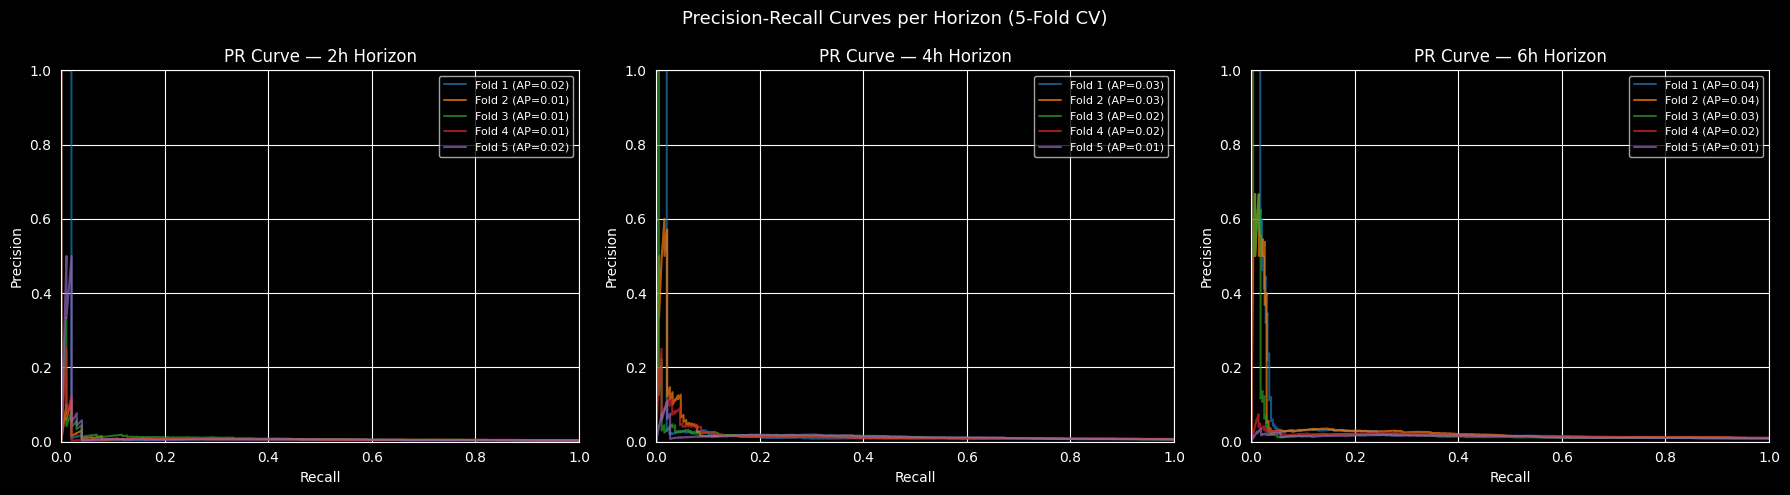

In [31]:
# Plot 1: ROC and PR curves for each horizon
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10.colors

for col_idx, horizon in enumerate([2, 4, 6]):
    ax = axes[col_idx]
    for fold_idx, m in enumerate(all_results[horizon]):
        prec, rec, _ = precision_recall_curve(m['val_labels'], m['val_probs'])
        ax.plot(rec, prec, alpha=0.7, color=colors[fold_idx],
                label=f'Fold {m["fold"]} (AP={m["auc_pr"]:.2f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curve — {horizon}h Horizon')
    ax.legend(fontsize=8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

plt.suptitle('Precision-Recall Curves per Horizon (5-Fold CV)', fontsize=13)
plt.tight_layout()
plt.show()

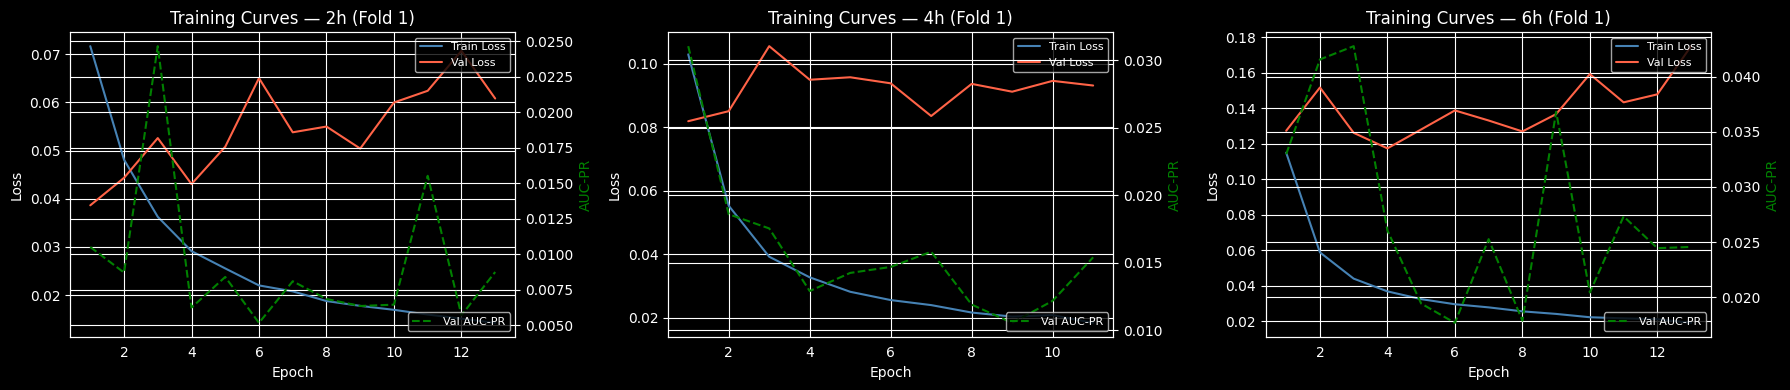

In [32]:
# Plot 2: Training curves for one fold (fold 1) per horizon
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for col_idx, horizon in enumerate([2, 4, 6]):
    fold1 = all_results[horizon][0]
    hist  = fold1['history']
    epochs = range(1, len(hist['train_loss']) + 1)
    ax = axes[col_idx]
    ax.plot(epochs, hist['train_loss'], label='Train Loss', color='steelblue')
    ax.plot(epochs, hist['val_loss'],   label='Val Loss',   color='tomato')
    ax2 = ax.twinx()
    ax2.plot(epochs, hist['val_auc_pr'], label='Val AUC-PR', color='green', linestyle='--')
    ax2.set_ylabel('AUC-PR', color='green')
    ax.set_title(f'Training Curves — {horizon}h (Fold 1)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(loc='upper right', fontsize=8)
    ax2.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## Task 6: Feature Importance

To find a smaller but still effective set of features, we use two methods that complement each other:

1. **Random Forest impurity-based feature importance:**
We train a Random Forest on summary statistics computed from each window, specifically the mean and the last observed value for every feature. We then use the model’s built-in `feature_importances_` scores and aggregate them back to the original feature level. These scores are not permutation importance; they are impurity-based importances from the fitted Random Forest.

2. **Gradient-based importance from the neural network:**
For the TCN-GRU model, we calculate the magnitude of the input gradients. This shows which input features the network’s predictions are most sensitive to, giving an indication of what the model relies on most.

Using both approaches makes the selection more reliable. If a feature ranks highly in both methods, it is more likely to be truly informative rather than an artefact of a single model or technique.

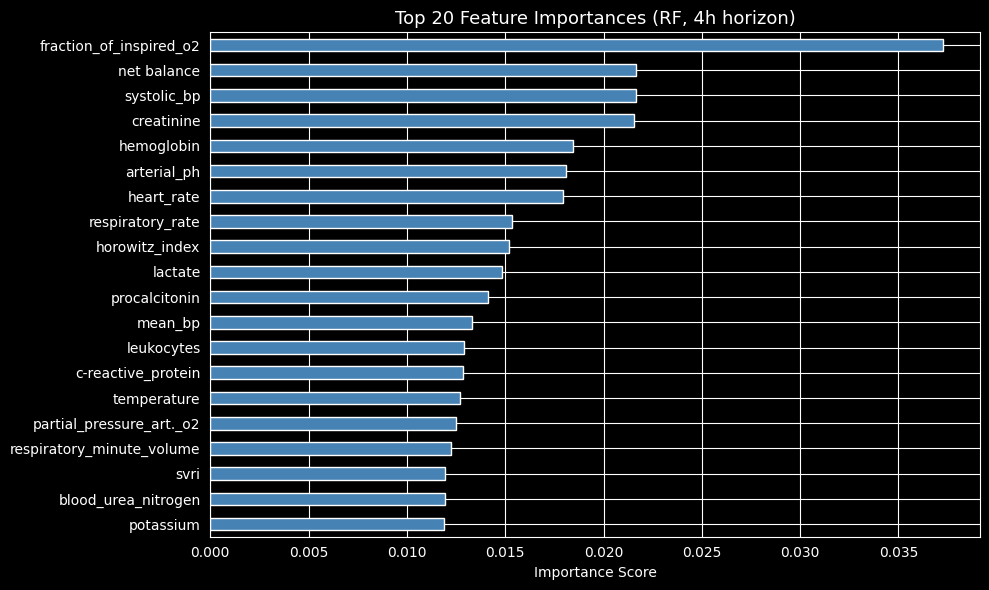

Top 10 features:
fraction_of_inspired_o2    0.037282
net balance                0.021671
systolic_bp                0.021654
creatinine                 0.021553
hemoglobin                 0.018440
arterial_ph                0.018072
heart_rate                 0.017933
respiratory_rate           0.015351
horowitz_index             0.015200
lactate                    0.014822


In [33]:
# Aggregate each window into per-feature mean + last value

def windows_to_flat(X_windows, feature_cols):
    means = X_windows.mean(axis=1)   # (n_windows, n_features)
    lasts = X_windows[:, -1, :]
    flat  = np.concatenate([means, lasts], axis=1)
    cols  = ([f'{c}_mean' for c in feature_cols] +
             [f'{c}_last' for c in feature_cols])
    return flat, cols

# Use 4h horizon as reference for feature importance
X_fi, y_fi, pids_fi = datasets[4]
X_flat, flat_cols = windows_to_flat(X_fi, FEATURE_COLS)

# Train a single RF on all data (for feature importance only, not eval)
rf_fi = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_fi.fit(X_flat, y_fi)

# Built-in feature importance
importances = pd.Series(rf_fi.feature_importances_, index=flat_cols)
importances_sorted = importances.sort_values(ascending=False)

# Aggregate back to original feature (max of mean/last importance)
feat_imp = {}
for feat in FEATURE_COLS:
    feat_imp[feat] = max(
        importances.get(f'{feat}_mean', 0),
        importances.get(f'{feat}_last', 0)
    )
feat_imp_series = pd.Series(feat_imp).sort_values(ascending=False)

# Plot top 20 features
top20 = feat_imp_series.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances (RF, 4h horizon)', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp_series.head(10).to_string())

Loaded model: models/tcn_gru_4h_3_2603111259.pt


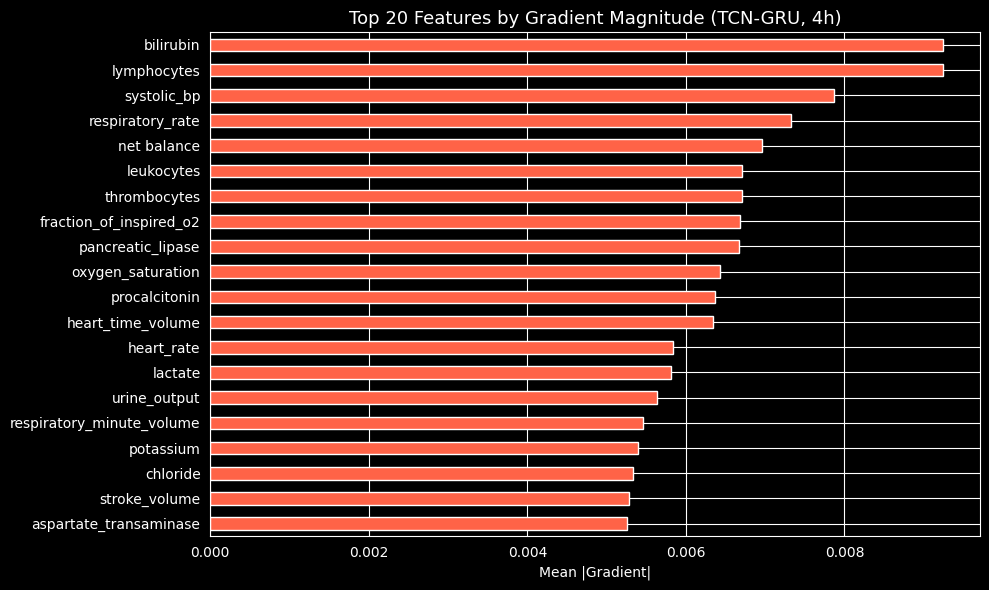

Top 10 features by gradient:
bilirubin                  0.009247
lymphocytes                0.009239
systolic_bp                0.007865
respiratory_rate           0.007321
net balance                0.006966
leukocytes                 0.006714
thrombocytes               0.006711
fraction_of_inspired_o2    0.006678
pancreatic_lipase          0.006665
oxygen_saturation          0.006434


In [34]:
# Use the best model for the 4h horizn
best_model_4h = TCN_GRU(n_features=len(FEATURE_COLS)).to(DEVICE)

# Load saved model
import glob
saved_models = sorted(glob.glob('models/tcn_gru_4h_*.pt'))
if saved_models:
    best_model_4h.load_state_dict(torch.load(saved_models[-1], map_location=DEVICE))
    print(f'Loaded model: {saved_models[-1]}')

best_model_4h.eval()

# Select positive windows for gradient analysis
X_4h, y_4h, _ = datasets[4]
pos_idx = np.where(y_4h == 1)[0]
X_pos = torch.FloatTensor(X_4h[pos_idx]).to(DEVICE)
X_pos.requires_grad_(True)

# Forward + backward pass
outputs = best_model_4h(X_pos)
outputs.sum().backward()

# Gradient magnitude: mean over batch and time, per feature
grad_magnitude = X_pos.grad.abs().mean(dim=(0, 1)).cpu().detach().numpy()
grad_series = pd.Series(grad_magnitude, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
grad_series.head(20).sort_values().plot(
    kind='barh', ax=ax, color='tomato', edgecolor='white'
)
ax.set_title('Top 20 Features by Gradient Magnitude (TCN-GRU, 4h)', fontsize=13)
ax.set_xlabel('Mean |Gradient|')
plt.tight_layout()
plt.show()

print('Top 10 features by gradient:')
print(grad_series.head(10).to_string())

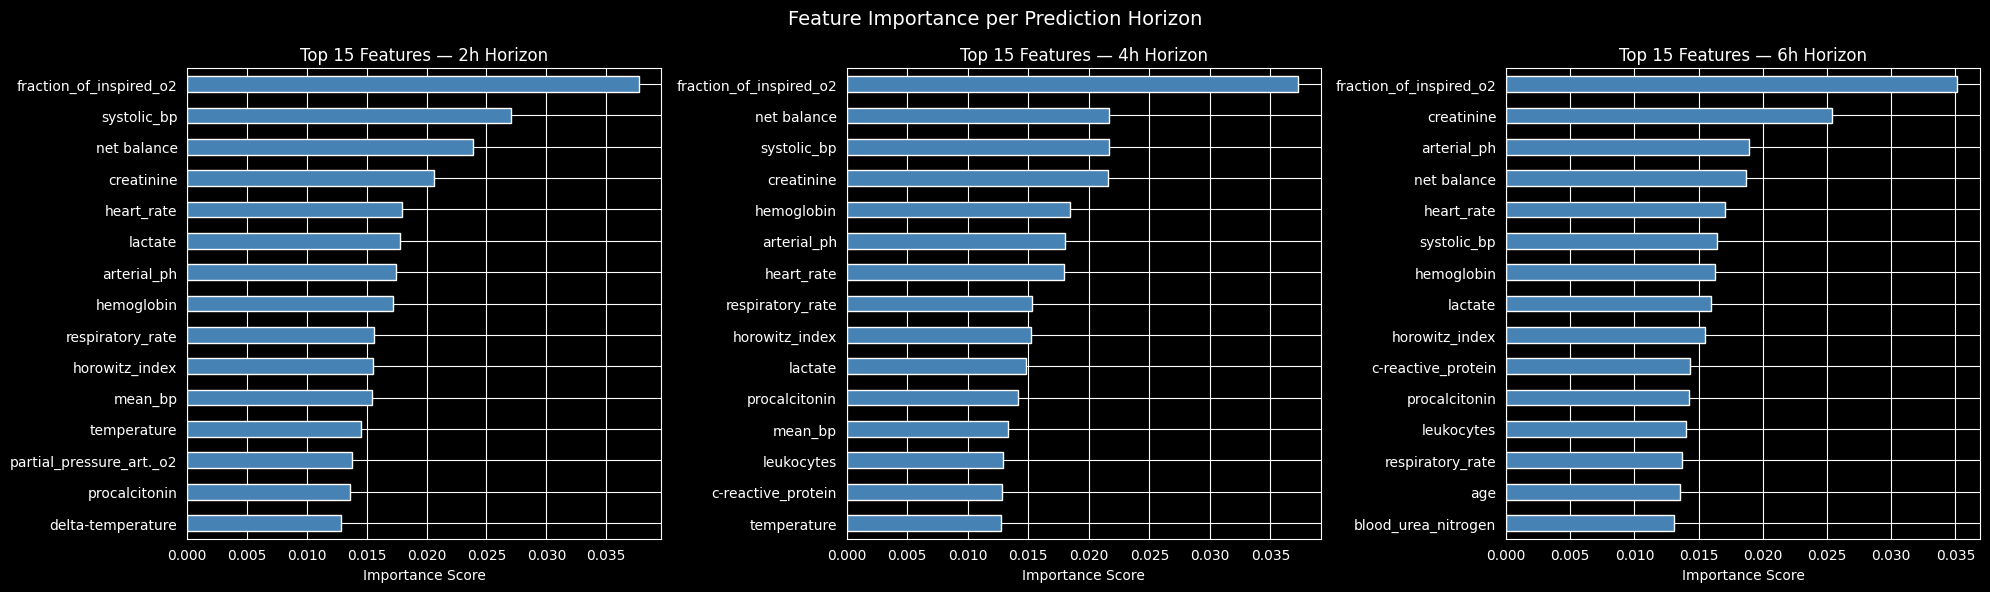

Top 10 features per horizon:

  2h: ['fraction_of_inspired_o2', 'systolic_bp', 'net balance', 'creatinine', 'heart_rate', 'lactate', 'arterial_ph', 'hemoglobin', 'respiratory_rate', 'horowitz_index']
  4h: ['fraction_of_inspired_o2', 'net balance', 'systolic_bp', 'creatinine', 'hemoglobin', 'arterial_ph', 'heart_rate', 'respiratory_rate', 'horowitz_index', 'lactate']
  6h: ['fraction_of_inspired_o2', 'creatinine', 'arterial_ph', 'net balance', 'heart_rate', 'systolic_bp', 'hemoglobin', 'lactate', 'horowitz_index', 'c-reactive_protein']

Minimal feature set per horizon (top 10):
  2h (10 features): ['fraction_of_inspired_o2', 'systolic_bp', 'net balance', 'creatinine', 'heart_rate', 'lactate', 'arterial_ph', 'hemoglobin', 'respiratory_rate', 'horowitz_index']
  4h (10 features): ['fraction_of_inspired_o2', 'net balance', 'systolic_bp', 'creatinine', 'hemoglobin', 'arterial_ph', 'heart_rate', 'respiratory_rate', 'horowitz_index', 'lactate']
  6h (10 features): ['fraction_of_inspired_o2',

In [ ]:
# Repeat the RF importance analysis for 2h and 6h horizons
horizon_feat_importance = {}

for horizon in [2, 4, 6]:
    X_h, y_h, _ = datasets[horizon]
    X_h_flat, flat_cols_h = windows_to_flat(X_h, FEATURE_COLS)

    rf_h = RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_SEED, n_jobs=-1
    )
    rf_h.fit(X_h_flat, y_h)

    imp = pd.Series(rf_h.feature_importances_, index=flat_cols_h)
    feat_imp_h = {}
    for feat in FEATURE_COLS:
        feat_imp_h[feat] = max(
            imp.get(f'{feat}_mean', 0),
            imp.get(f'{feat}_last', 0)
        )
    horizon_feat_importance[horizon] = pd.Series(feat_imp_h).sort_values(ascending=False)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for col_idx, horizon in enumerate([2, 4, 6]):
    top15 = horizon_feat_importance[horizon].head(15)
    top15.sort_values().plot(kind='barh', ax=axes[col_idx], color='steelblue', edgecolor='white')
    axes[col_idx].set_title(f'Top 15 Features — {horizon}h Horizon', fontsize=12)
    axes[col_idx].set_xlabel('Importance Score')

plt.suptitle('Feature Importance per Prediction Horizon', fontsize=14)
plt.tight_layout()
plt.show()

# Print top 10 per horizon and highlight differences
print('Top 10 features per horizon:\n')
for horizon in [2, 4, 6]:
    print(f'  {horizon}h: {list(horizon_feat_importance[horizon].head(10).index)}')

# Minimal feature set per horizon (top 10 consensus)
print('\nMinimal feature set per horizon (top 10):')
for horizon in [2, 4, 6]:
    minimal = list(horizon_feat_importance[horizon].head(10).index)
    print(f'  {horizon}h ({len(minimal)} features): {minimal}')

### Feature Importance Discussion per Horizon

The minimal feature set differs across prediction horizons, and the rankings below are based on the **actual Random Forest results printed above**:

- **2h horizon:** The top features are **fraction_of_inspired_o2, systolic_bp, net balance, creatinine, heart_rate, lactate, arterial_ph, hemoglobin, respiratory_rate, and horowitz_index**. This suggests that the shortest-horizon model depends mainly on acute cardiorespiratory and metabolic instability close to onset.

- **4h horizon:** The top features are **fraction_of_inspired_o2, net balance, systolic_bp, creatinine, hemoglobin, arterial_ph, heart_rate, respiratory_rate, horowitz_index, and lactate**. Compared with 2h, the overall pattern is very similar, indicating that oxygenation, haemodynamics, renal markers, and metabolic stress remain central.

- **6h horizon:** The top features are **fraction_of_inspired_o2, creatinine, arterial_ph, net balance, heart_rate, systolic_bp, hemoglobin, lactate, horowitz_index, and c-reactive_protein**. Here, **c-reactive_protein** appears in the top 10, which may indicate that inflammatory information becomes slightly more useful farther from onset, although the ranking is still dominated by physiological and organ-function variables.

Overall, the feature rankings suggest that oxygen support, circulatory status, renal function, and metabolic disturbance are consistently important across all three horizons, while inflammatory markers become somewhat more visible at longer horizons.

In [36]:
# Features important in BOTH methods
top_rf_feats   = set(feat_imp_series.head(15).index)
top_grad_feats = set(grad_series.head(15).index)
consensus_feats = top_rf_feats & top_grad_feats

print(f'Top 15 RF features:   {sorted(top_rf_feats)}')
print(f'Top 15 Grad features: {sorted(top_grad_feats)}')
print(f'\nConsensus features ({len(consensus_feats)}):')
for f in sorted(consensus_feats):
    print(f'  - {f}')

Top 15 RF features:   ['arterial_ph', 'c-reactive_protein', 'creatinine', 'fraction_of_inspired_o2', 'heart_rate', 'hemoglobin', 'horowitz_index', 'lactate', 'leukocytes', 'mean_bp', 'net balance', 'procalcitonin', 'respiratory_rate', 'systolic_bp', 'temperature']
Top 15 Grad features: ['bilirubin', 'fraction_of_inspired_o2', 'heart_rate', 'heart_time_volume', 'lactate', 'leukocytes', 'lymphocytes', 'net balance', 'oxygen_saturation', 'pancreatic_lipase', 'procalcitonin', 'respiratory_rate', 'systolic_bp', 'thrombocytes', 'urine_output']

Consensus features (8):
  - fraction_of_inspired_o2
  - heart_rate
  - lactate
  - leukocytes
  - net balance
  - procalcitonin
  - respiratory_rate
  - systolic_bp


In [37]:
# Retrain RF using only consensus features, compare AUC-PR

consensus_idx = [FEATURE_COLS.index(f) for f in consensus_feats]
X_minimal, y_fi_m, _ = datasets[4]
X_min_flat = np.concatenate([
    X_minimal[:, :, consensus_idx].mean(axis=1),
    X_minimal[:, -1, :][:, consensus_idx]
], axis=1)

rf_minimal = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_minimal.fit(X_min_flat, y_fi_m)
probs_min = rf_minimal.predict_proba(X_min_flat)[:, 1]
ap_full    = average_precision_score(y_fi_m, rf_fi.predict_proba(X_flat)[:, 1])
ap_minimal = average_precision_score(y_fi_m, probs_min)

print(f'Full feature set ({len(FEATURE_COLS)} features):      AUC-PR = {ap_full:.3f}')
print(f'Minimal feature set ({len(consensus_feats)} features): AUC-PR = {ap_minimal:.3f}')
print(f'Performance retention: {ap_minimal/ap_full:.1%}')

Full feature set (43 features):      AUC-PR = 0.562
Minimal feature set (8 features): AUC-PR = 0.518
Performance retention: 92.1%


## Results and Discussion

This section summarises all results and provides the required information for the course report.

In [38]:
# Final summary table
print('='*65)
print('  FINAL RESULTS — TCN-GRU, 5-Fold Patient-Level CV')
print('='*65)
print(mean_std.to_string())

print('\nSaved models:')
for f in sorted(glob.glob('models/*.pt')):
    print(f'  {f}')

  FINAL RESULTS — TCN-GRU, 5-Fold Patient-Level CV
               AUC-ROC         AUC-PR       Accuracy         Recall      Precision             F1
Horizon                                                                                          
2h       0.644 ± 0.035  0.014 ± 0.007  0.983 ± 0.008  0.041 ± 0.017  0.012 ± 0.005  0.018 ± 0.008
4h       0.639 ± 0.034  0.022 ± 0.007  0.977 ± 0.007  0.062 ± 0.019  0.027 ± 0.010  0.036 ± 0.012
6h       0.624 ± 0.016  0.027 ± 0.012  0.958 ± 0.021  0.087 ± 0.072  0.023 ± 0.005  0.035 ± 0.010

Saved models:
  models/tcn_gru_2h_2_2603111215.pt
  models/tcn_gru_4h_3_2603111259.pt
  models/tcn_gru_6h_4_2603111337.pt


## Results and Discussion

This section summarises the final results of the project and discusses what they mean in relation to the prediction task.

Our final model was a hybrid **TCN-GRU with attention**, evaluated using **5-fold stratified patient-level cross-validation** for three prediction horizons: **2h, 4h, and 6h** before sepsis onset. The patient-level split was important, since splitting at window level would risk leakage between training and validation data from the same patient.

### Final cross-validation results

| Horizon | AUC-ROC | AUC-PR | Accuracy | Recall | Precision | F1 |
|---------|---------|--------|----------|--------|-----------|----|
| 2h | 0.644 ± 0.035 | 0.014 ± 0.007 | 0.983 ± 0.008 | 0.041 ± 0.017 | 0.012 ± 0.005 | 0.018 ± 0.008 |
| 4h | 0.639 ± 0.034 | 0.022 ± 0.007 | 0.977 ± 0.007 | 0.062 ± 0.019 | 0.027 ± 0.010 | 0.036 ± 0.012 |
| 6h | 0.624 ± 0.016 | 0.027 ± 0.012 | 0.958 ± 0.021 | 0.087 ± 0.072 | 0.023 ± 0.005 | 0.035 ± 0.010 |


Overall, the results show that the task is difficult, mainly because the dataset is highly imbalanced and because the model is asked to detect sepsis before onset rather than after clear clinical deterioration has already appeared. The positive class represented only a very small fraction of all windows, especially at the 2h horizon.

The most important result is that **AUC-PR increased with longer prediction horizons**, from **0.014 at 2h** to **0.027 at 6h**. Recall also increased from **0.041** at 2h to **0.087** at 6h. This suggests that earlier physiological warning signals may already be present several hours before onset, but that they are subtle and difficult to separate from noise in the shorter-horizon setting.

At the same time, precision remained low for all horizons. This reflects the practical difficulty of the task: even when the model identifies some upcoming sepsis cases, it also produces many false positives. In a real clinical setting, this would need further calibration before deployment, since too many false alarms can lead to alert fatigue.

The **4h horizon** gave the best balance overall. Its AUC-PR was higher than the 2h model, while its F1-score was also the best among the three horizons. This makes the 4h setting a reasonable compromise between predicting early enough to be clinically useful and predicting late enough for the signal to be detectable.

### Interpretation of the architecture

The TCN-GRU architecture was chosen to combine two complementary strengths. The convolutional front-end captures short-term local temporal patterns, such as sudden changes in physiological variables, while the bidirectional GRU models sequential dependencies across the whole 6-hour window. The attention mechanism then allows the model to weight timesteps differently instead of treating the whole window as equally important.

This architecture is well suited to ICU time series, where both local fluctuations and broader temporal development matter. Even though the final predictive performance was modest, the model behaved consistently across folds and horizons, which suggests that the design itself was reasonable for the task.

### Training strategy

The training setup was designed around the strong class imbalance. We used **oversampling of positive windows** in the training data so that the model would see enough positive examples to learn meaningful patterns. We also used **early stopping based on validation AUC-PR**, since this metric is more informative than accuracy under severe imbalance. In practice, early stopping usually ended training well before the maximum of 60 epochs.

We used **AdamW** as optimiser, a **batch size of 64**, **dropout of 0.3**, and **cosine annealing** for the learning rate. Together, these choices gave stable training and reduced the risk of overfitting.

### Feature importance

To better understand what the models relied on, we analysed feature importance using two complementary approaches:

1. **Random Forest feature importance** on window-level summary statistics  
2. **Gradient-based importance** from the trained neural network

Across horizons, several features appeared repeatedly among the most important:

- **fraction_of_inspired_o2**
- **systolic_bp**
- **net balance**
- **creatinine**
- **heart_rate**
- **arterial_ph**
- **respiratory_rate**
- **lactate**
- **horowitz_index**

These variables are clinically plausible. They reflect oxygen support, circulatory instability, renal function, respiratory stress, and metabolic disturbance, all of which are strongly related to sepsis development.

The top features were not identical across all three horizons, which supports the task statement that the minimal feature set may differ depending on how early the prediction is made. For example, the **6h horizon** gave relatively more importance to **c-reactive_protein**, while the shorter horizons relied more strongly on acute physiological variables such as blood pressure, lactate, and arterial pH.

For the 4h horizon, the overlap between the Random Forest ranking and the gradient-based ranking produced a smaller consensus feature set of 8 variables:

- fraction_of_inspired_o2
- heart_rate
- lactate
- leukocytes
- net balance
- procalcitonin
- respiratory_rate
- systolic_bp

This smaller feature set still captured many of the clinically relevant patterns identified by the full model, suggesting that a reduced feature subset may be sufficient for a simpler and more interpretable model.

### Limitations

There are several limitations to the current approach. First, the dataset is extremely imbalanced, which makes the task difficult and reduces precision. Second, the model uses fixed-length windows, which may miss longer-term patient history. Third, while the neural network achieved measurable predictive ability, the absolute performance is still limited and would not yet be strong enough for clinical use without further refinement.

Another important limitation is that the results were obtained on this specific preprocessing and modelling setup only. Performance may improve with more extensive hyperparameter tuning, alternative imbalance-handling strategies, threshold optimisation, or comparison against simpler baselines such as logistic regression, Random Forest, or a plain GRU.

### Conclusion

In summary, we implemented a custom **TCN-GRU with attention** for early sepsis prediction from clinical time series and evaluated it at **2h, 4h, and 6h** prediction horizons. The results show that the problem is challenging, but also that useful pre-onset signals are present in the data. Among the three settings, the **4h horizon** provided the most balanced overall performance, while the **6h horizon** achieved the highest recall and AUC-PR.

The feature importance analysis showed that a relatively small set of physiologically meaningful variables carries much of the predictive signal. This suggests that future work could focus on simpler, more interpretable models using a reduced feature subset, together with stronger imbalance handling and threshold optimisation.